In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [19]:
n = 100
ni = 10
m = 5
h = 1.0/n

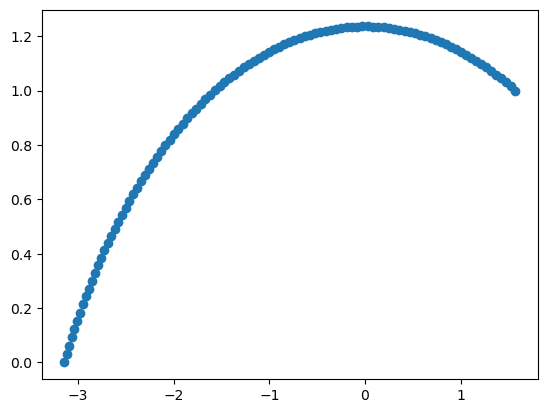

In [ ]:
dell = 1e-6
alpha0 = 1
dalpha = 0.01

def g(Y,t):
    k = len(Y)
    V = np.zeros(k)
    V[0] = Y[1]
    V[1] = -(math.pi**2)*(Y[0]+1)/4
    return V

def rungeKutta(y, t, dt):
    C1 = g(y, t)
    C2 = g(y + dt*C1/2, t + dt/2)
    C3 = g(y + dt*C2/2, t + dt/2)
    C4 = g(y + dt*C3,   t + dt)
    return y + dt*(C1 + 2*C2 + 2*C3 + C4)/6

def f(x):
    Y = np.zeros(2)
    Y[0] = 0
    Y[1] = x
    for i in range(n):
        xi = h*i
        Y = rungeKutta(Y,xi,h)
    
    return Y[0]-1

def secant(nu,dell,x,dx):
    k = 0
    x1 = x + dx
    while (np.abs(dx) > dell) and (k < nu):
        d = f(x1)-f(x)
        x2 = x1 - f(x1)*(x1-x)/d
        x = x1
        x1 = x2
        dx = x1 - x
        k = k + 1

    return x1 
    

Y1 = np.zeros(n+1)
Y2 = np.zeros(n+1)
Y = np.zeros(2)

Y1[0] = Y[0] = 0
Y2[0] = Y[1] = secant(ni,dell,alpha0,dalpha)
for i in range(n):
    x = h*i
    Y = rungeKutta(Y,x,h)
    Y1[i+1] = Y[0]
    Y2[i+1] = Y[1]

plt.scatter(-Y2,Y1)